BASIC CLASSIFICATION: Classify images of clothing

This guide trains a neural network model to classify images of clothing, like sneakers and shirts.
This guide uses tf.keras, a high-level API to build and train models in TensorFLow

In [25]:
#Tensorflow and tf,keras
import tensorflow as tf

#Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.version)

<module 'tensorflow._api.v2.version' from '/home/izy/Documents/Project/TensorflowPractice/venv/lib/python3.12/site-packages/tensorflow/_api/v2/version/__init__.py'>


IMPORT THE FASHION MNIST DATASET

We will use the Fashon MNIST dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels).

Fashion MNIST is intended as a drop in replacement for the classic MNIST dataset-often used as the " Hello, world " of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits(0,1,2,etc) in a format identical to that of the articles of the clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithim works as expected. They are good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images evaluate how accurately the network learned to classify images. You can access the fashion MNIST directly from TensorFlow.Import and load the Fashion MNIST data directly from TensorFlow.

In [26]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

The images are 28x28 Numpy arrays, with pixel values ranging from 0 to 255. The labels are an array of integers, ranging from 0 to 9. These correspond to the clothing the image represents 

 ![alt text](image.png)

In [27]:
fashion_mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [28]:
print(train_labels[0:10])

[9 0 0 3 0 2 7 2 5 5]


Each image is mapped to a single label. since the class names are not included in the dataset, we store them to use later when plotting the images

In [29]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

EXPLORE THE DATA

Let's explore the format of the dataset before training the model. The following shows there are 60,000 images in the training set, with each image represented as 28x28 pixels

In [30]:
train_images.shape

(60000, 28, 28)

In [31]:
len(train_labels)

60000

Each label is an integer between 0 and 9

In [32]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [33]:
test_images.shape

(10000, 28, 28)

In [34]:
len(test_labels)

10000

PREPROCESS THE DATA

The data must be preprocessed before training the network, If you inspect the first image in the training set, you will see the pixel values fall in range of 0 to 255

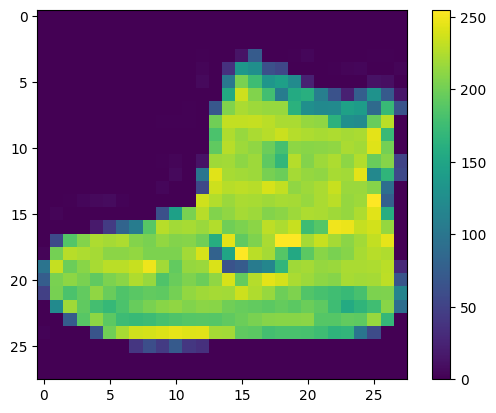

In [35]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the training and the testing set be preprocessed in the same way:

In [36]:
train_images = train_images / 255.0
test_images = test_images / 255.0

To verify that the data is in correct format and that you are ready to build and train the network, lets display the first 25 images from the training set and display the class name below each image.

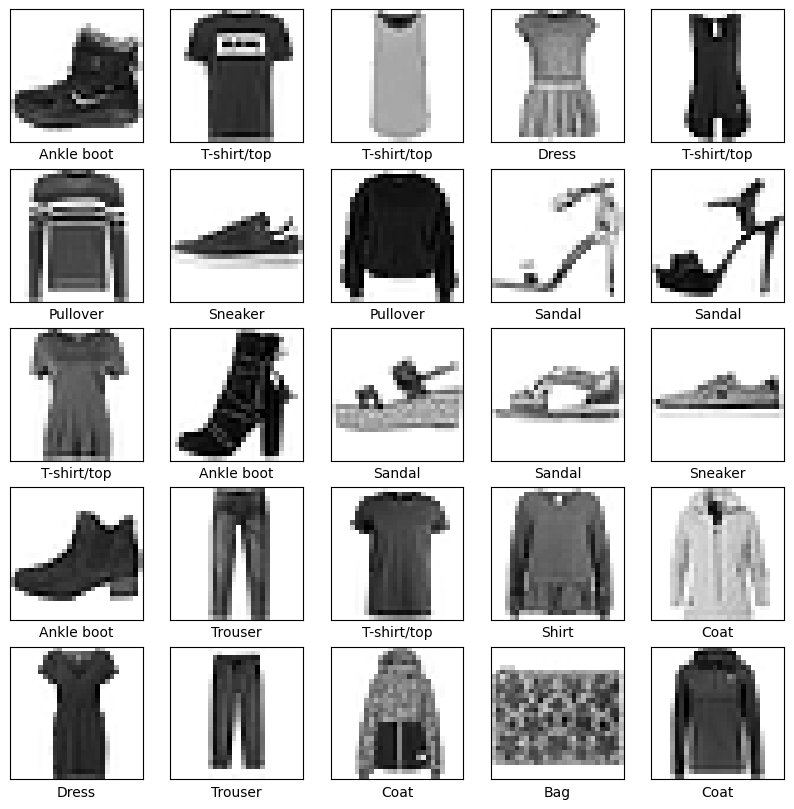

In [37]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

BUILD THE MODEL

Building the neural network requires configuring the layers of the model, then compiling the model

Set Up The Layers

The basic building block of a neural network is the layer. layers extract representations from the data fed into them, Hopefully, these representations are meaningful for the problem at hand.
Most of the deep learning consists of chaining together simple layers. Most layers, such as tf.Keras.layers.Dense, have the parameters that are learned during the training

In [38]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

The first layer in the network, tf.keras.layers.Flatten, transforms the format of the images from a two-dimensional array(0f 28 by 28 pixels) to a one dimensional array (of 28*28 = 784 pixels). Think of this layer as unstacking rows of pixels in the image and lining them up. This layer has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists on a sequence of two tf.keras.layers.Dense layers. These are densely connected, or fully connected, neural layers. The first Dense layer has 128 nodes(or neurons). The second(and the last) layer returns a logits array with length of 10. Each node contains a score that indicates the current image belongs to one of the 10 classes.

COMPILE THE MODEL

Before the model is ready for training, it needs a few more settings. These are added during the model's compile step:

1. Optimizer - This is how the model is updated based on the data it sees and its loss function.

2. Loss function - This measures how accurate the model is during the training. You want to minimize this loss function to 'steer' the model in the right direction.

3. Metrics - Used to monitor the training and testing steps. The following example uses accuracy, the function of the images that are correctly classified.

In [39]:
model.compile(optimizer='adam', 
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

TRAIN THE MODEL

Training the neural network model requires the following steps:

1. Feed the training data to the model.In this example, the training data is in the train_images and the train_labels array.

2. The model learns to associate images and labels

3. You ask the model to make predictions about a test set in this example, the test_images array.

4. Verify that the predictions match the labels from the test_labels array.

FEED THE MODEL

To start training, call the model.fit method-so called because it "fits" the model to the training data.


In [40]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8260 - loss: 0.4959
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8659 - loss: 0.3722
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8773 - loss: 0.3365
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8860 - loss: 0.3117
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8923 - loss: 0.2942
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8967 - loss: 0.2807
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9008 - loss: 0.2660
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9051 - loss: 0.2549
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9090 - loss: 0.2452
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9105 - loss: 0.2377


As the model trains, the loss and accuracy metrics are displayed. This model reaches an accuracy of about ~91% on the training data.

EVALUATE ACCURACY

Next we compare how the model perfoms on the test dataset:

In [41]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 0s - 849us/step - accuracy: 0.8839 - loss: 0.3415

Test accuracy: 0.883899986743927


It turns out that the accuracy on the test dataset is a litte less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents "OVERFITTING". Overfitting happens when a ML model performs worse on new, previously unseen inputs than it does on the training data. An  overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. 

MAKE PREDICTIONS

With the model trained, you can use it to make predictions about some images, Attach a softmax layer to convert the models linear outputs-logits to probabilities, which should be easier to interpret.

In [42]:
probability_model = tf.keras.Sequential(
    [
    model,
    tf.keras.layers.Softmax()
    ])

predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


In [43]:
predictions[0]

array([7.7956592e-08, 7.2040187e-08, 2.9659710e-09, 3.1580461e-07,
       1.3117115e-06, 7.4884162e-04, 6.4555809e-07, 2.3088409e-02,
       3.9071024e-06, 9.7615641e-01], dtype=float32)

A prediction is an array of 10 numbers. They represent the model's confidence that the image corresponds to eah of the 10 different articles of clothing. You can see which label has the highest confidence value.

In [44]:
np.argmax(predictions[0])

np.int64(9)

So, the model is most confident that this image is an ankle boot, or class_names[9]. Examining the test labels shows that this classification is correct.

In [45]:
test_labels[0]

np.uint8(9)

Define functions to graph the full set of 10 class predictions

In [57]:
def plot_image(i, predictions_array, true_label,  img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),
                                         color=color)
    
def plot_value_array(i, predictions_array, true_labels):
    true_label = true_labels[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

VERIFY PREDICTIONS

With the model trained, you can use it to make predictions about some images.

Lets look at the 0th image, predictions, and prediction array. Correct prediction labels are blue and incorrect prediction labels are red. The number gives the percentage(out of 100) for the predicted label

In [58]:
test_labels[0]

np.uint8(9)

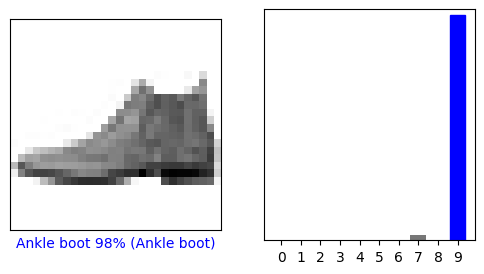

In [59]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)

plot_value_array(i, predictions[i], test_labels)
plt.show()

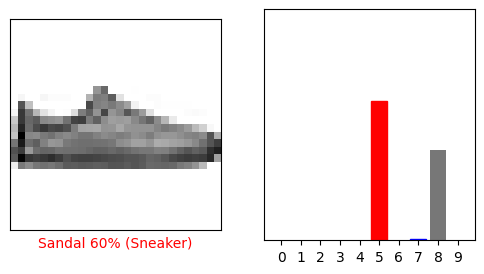

In [60]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

Let's plot several images with their predictions. Note that the model can be wrong even when very confident

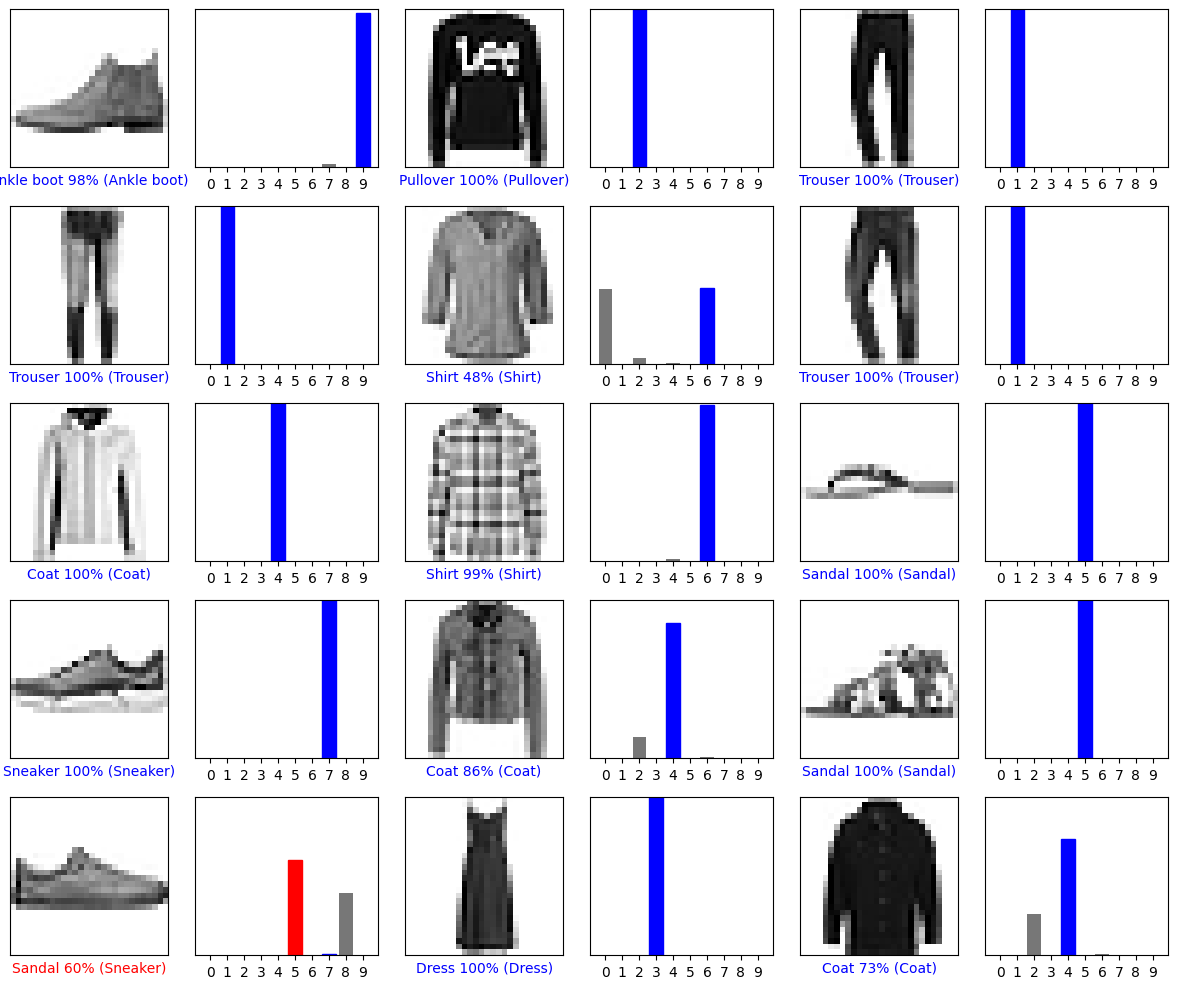

In [86]:
#Plot the first X test images, their predicted labels, and the true labels.
# Coloe correct prediction in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

USE THE TRAINED MODEL

Finally, use the trained model to make the prediction about a single image

In [87]:
#Grab  an image from the test dataset.
img = test_images[1]

print(img.shape)

(28, 28)


tf.keras models are optimized to make predictions on a batch, or collection, of examples at once. Accordingly, even though you're using a single image, you need to add it to a list. 

In [88]:
#Add the image to a batch where it's the only member.
img = (np.expand_dims(img, 0))

print(img.shape)


(1, 28, 28)


Now predict the correct label for this image

In [89]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[1.1399076e-05 1.3380788e-11 9.9923706e-01 3.9934375e-12 7.4191974e-04
  7.6610863e-11 9.6593349e-06 1.7421671e-15 3.6842803e-11 7.9762301e-14]]


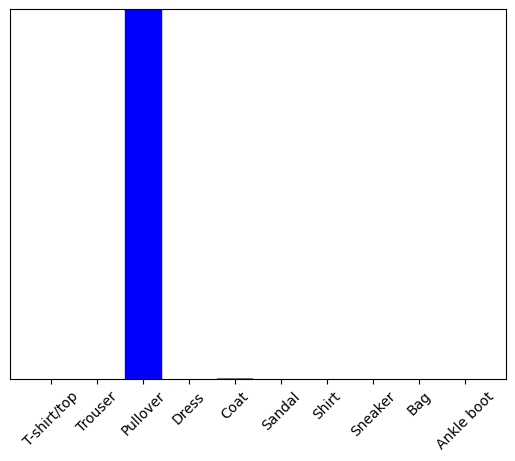

In [90]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

tf.keras.model.predict returns a list of lists-one list for eah image int the batch of the data. Grab the predictions for our(only) image in the batch

In [92]:
np.argmax(predictions_single[0])

np.int64(2)

In [93]:
# MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.